### Notebook for developing and testing a new MAF stacker class that will calculate an estimate of the DCR second moment additive bias for an "average" galaxy 

In [6]:
# from rubin_sim import maf
# from rubin_sim.data import get_data_dir

try:
    from rubin_sim.data import get_baseline
except ImportError:
    from rubin_scheduler.data import get_baseline
# import rubin_sim
# from rubin_sim import data
from rubin_sim.data import get_baseline
# import healpy as hp
import numpy as np
# import sqlite3
# from astropy.coordinates import SkyCoord
# import astropy.units as u
# import datashader as ds
import matplotlib.pyplot as plt
# import matplotlib as mpl
# from datashader.mpl_ext import dsshow
# import pandas as pd
import galsim
# import matplotlib.lines as mlines
# import os

from scipy.interpolate import interp1d

from astropy.modeling.models import BlackBody
from astropy import units as u


def BB(wave, temp, scale):
    temp = temp * u.K
    wave = wave * u.nm
    scale = scale * u.erg / (u.cm**2 * u.s * u.AA * u.sr)

    bb = BlackBody(temperature = temp, scale = scale)
    return bb(wave).value

def apply_filter(wvl, data, band = 'g', rm_leakage = True):
    '''
    wvl - a list of the wavelengths in angstroms
    data - a N x M list of SEDs, N = number of SEDs, M = len of wvl
    rm_leakage - whether to set the filter throughput to 0 for wavelengths where the throughput is less than 0.001 (removing filter leakage)
    returns data with the band filter applied to each SED
    '''
    
    filter_file = f'filter_files/total_{band}.dat'
    filter_band = np.loadtxt(filter_file).T #filter_band[0] -> wavelengths, filter_band[1] -> filter pass fraction

    # #remove filter leakage: set lower bound of filter to 0.001 throughput
    if rm_leakage:
        leakage_mask = filter_band[1] < 0.001
        filter_band[1][leakage_mask] = np.zeros(np.sum(leakage_mask))
    
    func = interp1d(filter_band[0], filter_band[1])
    SED_filter = func(wvl)
    
    
    return data * SED_filter

# for converting flux density to photon density
h  = 6.62607015e-27       # erg s
c  = 2.99792458e17        # nm / s
hc = h * c                # erg nm (≈ 1.986e-9)


# define filters as galsim objects:

datapath = galsim.meta_data.share_dir
filter_names = 'ugrizy'
filters = {}
for filter_name in filter_names:
    # filter_filename = os.path.join(datapath, 'bandpasses/LSST_{0}.dat'.format(filter_name))
    filter_filename = f'filter_files/noleak_{filter_name}.dat'
    # Here we create some galsim.Bandpass objects to represent the filters we're observing
    # through.  These include the entire imaging system throughput including the atmosphere,
    # reflective and refractive optics, filters, and the CCD quantum efficiency.  These are
    # also conveniently read in from two-column ASCII files where the first column is
    # wavelength and the second column is dimensionless throughput. The example filter files
    # units of nanometers for the wavelength type, so we specify that using the required
    # `wave_type` argument.
    filters[filter_name] = galsim.Bandpass(filter_filename, wave_type='nm')
    # For speed, we can thin out the wavelength sampling of the filter a bit.
    # In the following line, `rel_err` specifies the relative error when integrating over just
    # the filter (however, this is not necessarily the relative error when integrating over the
    # filter times an SED).
    filters[filter_name] = filters[filter_name].thin(rel_err=1e-4)
    # plt.plot(filters[filter_name].wave_list, filters[filter_name].__call__(filters[filter_name].wave_list))


# Mean wavelength in photon-density space using the GalSim SEDs 
def mean_wavelength_photon_density(sed, wavelengths_data):
    mean_wavelengths = {}
    sed_photon_density = sed(wavelengths_data)
    for band in filter_labels:
        throughput = filters[band](wavelengths_data)
        photon_density = sed_photon_density * throughput 
        numerator = np.trapezoid(y = wavelengths_data * photon_density, x = wavelengths_data)
        denominator = np.trapezoid(y = photon_density, x =  wavelengths_data)
        mean_wavelengths[band] = numerator / denominator
    return mean_wavelengths


### Chromatic refraction angle R of a light ray entering the atmosphere at a zenith angle $z_a$ is 
### $$\bold{R} = \bold{R}_{45} \tan{z_a},$$
### where $R_{45}$ is a constant depending on the wavelength of the light. 

Within a filter band, the bluer end of the band will be refracted more than the red band, this leads to the increase of the second moment of the PSF. 

DCR is an additive bias on the PSF second moment towards zenith, and is proportional to $R^2$, therefore 
$$ I_{DCR} = I_{DCR_{45}} \tan^2{z_a}$$
where $I_{DCR}$ is the shape moment along the zenith/altitude axis.
Below, we calculate the constants $I_{DCR_{45}}$ for each band (colloqiually called "widths"), assuming a gal SED in wavelength space. These values will be used in the MAF stacker.  

In [7]:
#Calculate the first and second moment shifts from DCR for flat SEDs ("average" Galaxy SED assumed to be flat)

filter_labels = ['u', 'g', 'r', 'i', 'z', 'y']

#get the filtered flat SED in photon density (in this case, these are exactly the response curves)
wavelengths_data = np.linspace(301, 1150, 10000)
filtered_flats = {}
for band in filter_labels:
    filtered_flats[band] = apply_filter(wavelengths_data , np.ones(10000), band, rm_leakage = True) * wavelengths_data / hc


# For further investigation: generate a SED for a 5000K blackbody, the assumed average SED for a standard calibration star
filtered_calib = {}
for band in filter_labels:
    filtered_calib[band] = apply_filter(wavelengths_data , BB(wavelengths_data, 5000, 1), band, rm_leakage = True) * wavelengths_data / hc
    


def get_shifts(zeniths, wavelengths_data, filtered_data):
    '''
    zeniths - list or array of zenith angles in degrees

    returns shifts (mean of refraction dist, 1st moment) and widths (variance of refraction dist, 2nd moment) dictionaries for each filter band
    shifts - a dictionary with keys = filter bands, values = list of means for each zenith angle
    widths - a dictionary with keys = filter bands, values = list of variances for each zenith angle

    Calculates the distribution of refraction angles (dN/dR) by multiplying the SED (dN/dwvl) by the derivative of refraction with respect to wavelength (dwvl/dR)
    '''

    dwvl = 0.1 #wavelength step
    wavelengths = np.arange(290, 1160, dwvl)
    
    #Matthew's atmospheric conditions
    pressure=70.0,  # kPa
    temperature=293.15,  # K
    H2O_pressure=0.0,
    
    #Pat and Josh's paper atmospheric conditions 
    pressure=69.328
    temperature=293.15
    H2O_pressure=1.067

    #setup storage for results
    widths = {}
    for band in filter_labels:
        widths[band] = []

    shifts = {}
    for band in filter_labels:
        shifts[band] = []

        
    for zenith in zeniths:
        
        #Get dR/dwavelength function using the detailed wavelengths list 
        refraction = galsim.dcr.get_refraction(
                wavelengths,
                zenith_angle=zenith * galsim.degrees,
                pressure=pressure,  # kPa
                temperature=temperature,  # K
                H2O_pressure=H2O_pressure,  # kPa
                ) * 180 * 3600 / np.pi #convert from radians to arcsec
        
        dR_dwvl = (refraction[1:] - refraction[0:-1])/dwvl
        wavelengths_midpoints = wavelengths[0:-1] + dwvl/2
        
        dRdwvl_func = interp1d(wavelengths_midpoints, dR_dwvl)
        
        
        #Map each wavelength in our SED to a refraction angle 
        refraction_wave = galsim.dcr.get_refraction(
                wavelengths_data,
                zenith_angle=zenith * galsim.degrees,
                pressure=pressure,  # kPa
                temperature=temperature,  # K
                H2O_pressure=H2O_pressure,  # kPa
                ) * 180 * 3600 / np.pi #convert from radians to arcsec
        
        
        filtered_refracted_data = {} #stores dNdR for each band 
        
        
        for band, filtered_flat in filtered_data.items():
            #data is proportional to photons/sec/cm^2/nm so is proportional to dN/dwvl
            #get dN/dR with (dN/dwvl) / (dR/dwvl)
            dNdR = np.abs(filtered_flat / dRdwvl_func(wavelengths_data))
            filtered_refracted_data[band] = dNdR

            #calculate the mean and variance refraction angle using np.trapezoid
            mean = np.trapezoid(x = refraction_wave, y = dNdR * np.array(refraction_wave).T) / np.trapezoid( x = refraction_wave, y = dNdR)
            # mean = np.sum(dNdR * np.array(refraction_wave).T) / np.sum(dNdR)
            variance = np.trapezoid(x = refraction_wave, y = dNdR * ((np.array(refraction_wave) - mean)**2).T) / np.trapezoid( x = refraction_wave, y = dNdR)
            # variance = np.sum(dNdR * (np.array(refraction_wave).T - mean)**2) / np.sum(dNdR)

            widths[band].append(variance)
            shifts[band].append(mean) #shift from the u band mean refraction angle
            
        

    return shifts, widths


        

zeniths = np.array([45])

shifts, widths= get_shifts(zeniths, wavelengths_data, filtered_flats)
shifts_calib, widths_calib = get_shifts(zeniths, wavelengths_data, filtered_calib)



for band in filter_labels:
    print(band, 'first moment (shift): ', np.round(shifts[band][0], 4), 'arcsec   second moment (width): ', np.round(widths[band][0], 4), 'arcsec^2') 
    print(band, 'CALIBRATION first moment (shift): ', np.round(shifts_calib[band][0], 4), 'arcsec   second moment (width): ', np.round(widths_calib[band][0], 4), 'arcsec^2') 
    



u first moment (shift):  39.3649 arcsec   second moment (width):  0.0256 arcsec^2
u CALIBRATION first moment (shift):  39.3458 arcsec   second moment (width):  0.0235 arcsec^2
g first moment (shift):  38.6723 arcsec   second moment (width):  0.0348 arcsec^2
g CALIBRATION first moment (shift):  38.6547 arcsec   second moment (width):  0.0322 arcsec^2
r first moment (shift):  38.2684 arcsec   second moment (width):  0.0061 arcsec^2
r CALIBRATION first moment (shift):  38.2699 arcsec   second moment (width):  0.0061 arcsec^2
i first moment (shift):  38.0814 arcsec   second moment (width):  0.0016 arcsec^2
i CALIBRATION first moment (shift):  38.0837 arcsec   second moment (width):  0.0016 arcsec^2
z first moment (shift):  37.9878 arcsec   second moment (width):  0.0004 arcsec^2
z CALIBRATION first moment (shift):  37.989 arcsec   second moment (width):  0.0004 arcsec^2
y first moment (shift):  37.9273 arcsec   second moment (width):  0.0003 arcsec^2
y CALIBRATION first moment (shift):  37

In [8]:
# Recreate above but with galsim functions (much faster)
#Calculate the first and second moment shifts from DCR for flat SEDs ("average" Galaxy SED assumed to be flat)

filter_labels = ['u', 'g', 'r', 'i', 'z', 'y']

wavelengths_data = np.linspace(301, 1150, 10000)

flat_flux = np.ones(len(wavelengths_data))
flat_table = galsim.LookupTable(wavelengths_data * 10, flat_flux, interpolant='linear')
flat_SED = galsim.SED(flat_table, wave_type='A', flux_type='flambda')

BB_flux = BB(wavelengths_data, 5000, 1) # 5000 K Blackbody spectrum
BB_table = galsim.LookupTable(wavelengths_data * 10, BB_flux, interpolant='linear')
BB_SED = galsim.SED(BB_table, wave_type='A', flux_type='flambda')


#Matthew's atmospheric conditions
pressure=70.0,  # kPa
temperature=293.15,  # K
H2O_pressure=0.0,

#Pat and Josh's paper atmospheric conditions 
pressure=69.328
temperature=293.15
H2O_pressure=1.067

def get_shifts_galsim(zenith, SED):

    #setup storage for results
    widths = {}
    shifts = {}

    for band in filter_labels:
        bandpass = filters[band]
        
        R, V = SED.calculateDCRMomentShifts(
            bandpass,
            zenith_angle = zenith * galsim.degrees,
            parallactic_angle = 0 * galsim.degrees,
            pressure = pressure,
            temperature = temperature,
            H2O_pressure = H2O_pressure) 
        
        shifts[band] = (R[-1]) * (180 * 3600 / np.pi) # arcsec
        widths[band] = (V[-1,-1]) * (180 * 3600 / np.pi)**2  #arcsec^2

    return shifts, widths


zenith = 45

shifts, widths= get_shifts_galsim(zenith, flat_SED)
shifts_calib, widths_calib = get_shifts_galsim(zenith, BB_SED)



for band in filter_labels:
    print(band, 'first moment (shift): ', np.round(shifts[band], 4), 'arcsec   second moment (width): ', np.round(widths[band], 4), 'arcsec^2') 
    print(band, 'CALIBRATION first moment (shift): ', np.round(shifts_calib[band], 4), 'arcsec   second moment (width): ', np.round(widths_calib[band], 4), 'arcsec^2') 
    


u first moment (shift):  39.3648 arcsec   second moment (width):  0.0256 arcsec^2
u CALIBRATION first moment (shift):  39.3458 arcsec   second moment (width):  0.0235 arcsec^2
g first moment (shift):  38.6723 arcsec   second moment (width):  0.0348 arcsec^2
g CALIBRATION first moment (shift):  38.6547 arcsec   second moment (width):  0.0322 arcsec^2
r first moment (shift):  38.2684 arcsec   second moment (width):  0.0061 arcsec^2
r CALIBRATION first moment (shift):  38.2699 arcsec   second moment (width):  0.0061 arcsec^2
i first moment (shift):  38.0814 arcsec   second moment (width):  0.0016 arcsec^2
i CALIBRATION first moment (shift):  38.0837 arcsec   second moment (width):  0.0016 arcsec^2
z first moment (shift):  37.9878 arcsec   second moment (width):  0.0004 arcsec^2
z CALIBRATION first moment (shift):  37.989 arcsec   second moment (width):  0.0004 arcsec^2
y first moment (shift):  37.9273 arcsec   second moment (width):  0.0003 arcsec^2
y CALIBRATION first moment (shift):  37

### The second moment magnitudes for zenith angle = 45 degrees (printed in the cell above) will be used in the stacker as the dcr2_magnitudes

In [9]:


# test DCR2 stacker
from rubin_sim.maf.stackers import BaseStacker
from rubin_sim.maf.stackers import ParallacticAngleStacker
from rubin_sim.maf.stackers import ZenithDistStacker

#Remove any existing Dcr2Stacker from the registry to avoid conflicts
bad_keys = [k for k in BaseStacker.registry if k.endswith(f".Dcr2Stacker")]
for k in bad_keys:
    BaseStacker.registry.pop(k, None)  # in case already registered
    

class Dcr2Stacker(BaseStacker):
    """
    
    NEEDS UPDATE FOR SECOND MOMENT CALCULATION
    Adapted from the original DcrStacker in rubin_sim.maf.stackers.dcrStacker
    
    Add columns representing the expected RA/Dec image spread contribution (variance) expected for
    an object due to differential chromatic refraction across the band, per visit.

    For DCR calculation, we also need zenithDistance, HA, and PA -- but these
    will be explicitly handled within this stacker so that setup is consistent
    and they run in order. If those values have already been calculated
    elsewhere, they will not be overwritten.

    Parameters
    ----------
    filter_col : `str`, optional
        The name of the column with filter names. Default 'filter'.
    altCol : `str`, optional
        Name of the column with altitude info. Default 'altitude'.
    ra_col : `str`, optional
        Name of the column with RA. Default 'fieldRA'.
    dec_col : `str`, optional
        Name of the column with Dec. Default 'fieldDec'.
    lstCol : `str`, optional
        Name of the column with local sidereal time. Default
        'observationStartLST'.
    site : `str` or `rubin_scheduler.utils.Site`, optional
        Name of the observory or a rubin_scheduler.utils.Site object.
        Default 'LSST'.
    mjdCol : `str`, optional
        Name of column with modified julian date.
        Default 'observationStartMJD'
    dcr2_magnitudes : dict, optional
        Magnitude of the DCR variance for each filter at an
        altitude/zenith distance of 45 degrees.
        Defaults u=0.0240, g=0.0308, r=0.0058, i=0.0015, z=0.0004, y=0.0003
        (all values should be in arcseconds^2).
    ra_and_dec : bool, optional
        Whether to break the DCR offset into RA and Dec components (True) 
        or just add a single ellipticity value in the direction toward zenith in a column 'dcr_var' (False, default). 
        If True, adds three columns: 'ra_dcr_var', 'dec_dcr_var', and 'ra_dec_dcr_cov'
        which can be thought of as shape moments. 
    

    Returns
    -------
    data : `numpy.array`
        Returns array with additional columns 'ra_dcr_amp' and 'dec_dcr_amp'
        with the DCR offsets for each observation.  Also runs ZenithDistStacker
        and ParallacticAngleStacker.
    """

    cols_added = ["dcr_var", "ra_dcr_var", "dec_dcr_var", "ra_dec_dcr_cov"]  # zenithDist, HA, PA

    def __init__(
        self,
        filter_col="band",
        alt_col="altitude",
        degrees=True,
        ra_col="fieldRA",
        dec_col="fieldDec",
        lst_col="observationStartLST",
        site="LSST",
        mjd_col="observationStartMJD",
        dcr2_magnitudes=None,
        ra_and_dec=False, #If False, just adds a single ellipticity value column implied to be in the direction toward zenith
                         #If True, adds two columns with the ellipticity broken into ra and dec components
    ):
        self.units = ["arcsec", "arcsec"]

        #Calculated using a flat SED in wavelength space, units are arcseconds squared
        if dcr2_magnitudes is None:
            self.dcr2_magnitudes = {
                "u": 0.0262, #FILL THIS IN WITH THE VALUES CALCULATED FOR A FLAT SED 
                "g": 0.0363,
                "r": 0.0063,
                "i": 0.0016,
                "z": 0.0004,
                "y": 0.0003,
            }
        else:
            self.dcr2_magnitudes = dcr2_magnitudes


        self.zd_col = "zenithDistance"
        self.pa_col = "PA"
        self.filter_col = filter_col
        self.ra_col = ra_col
        self.dec_col = dec_col
        self.degrees = degrees
        self.cols_req = [filter_col, ra_col, dec_col, alt_col, lst_col]
        #  'zenithDist', 'PA', 'HA' are additional columns required, coming
        #  from other stackers which must also be configured -- so we handle
        #  this explicitly here.
        self.zstacker = ZenithDistStacker(alt_col=alt_col, degrees=self.degrees)
        self.pastacker = ParallacticAngleStacker(
            ra_col=ra_col,
            dec_col=dec_col,
            mjd_col=mjd_col,
            degrees=self.degrees,
            lst_col=lst_col,
            site=site,
        )
        self.ra_and_dec = ra_and_dec
        # Note that RA/Dec could be coming from a dither stacker!
        # But we will assume that coord stackers will be handled separately.

    def _run(self, sim_data, cols_present=False):
        if cols_present:
            # Column already present in data; assume it is correct and does not
            # need recalculating.
            return sim_data
            
        # Need to make sure the Zenith stacker gets run first Call _run method
        # because already added these columns due to 'colsAdded' line.
        sim_data = self.zstacker.run(sim_data)
        sim_data = self.pastacker.run(sim_data)

        # if self.degrees:
        #     zenith_ang = sim_data[self.zd_col]
        #     # parallactic_angle = np.radians(sim_data[self.pa_col])
        # else:
        #     zenith_ang = np.rad2deg(sim_data[self.zd_col])
        #     # parallactic_angle = sim_data[self.pa_col]
        
        
        if self.degrees:
            zenith_tan = np.tan(np.radians(sim_data[self.zd_col]))
            parallactic_angle = np.radians(sim_data[self.pa_col])
        else:
            zenith_tan = np.tan(sim_data[self.zd_col])
            parallactic_angle = sim_data[self.pa_col]

        dcr_var = zenith_tan**2
        dcr_moment_rara = dcr_var * np.sin(parallactic_angle)**2 # shape moment along ra
        dcr_moment_decdec = dcr_var * np.cos(parallactic_angle)**2 # shape moment along dec
        dcr_moment_radec = dcr_var * np.sin(parallactic_angle) * np.cos(parallactic_angle) #covariance moment between ra and dec
        
        for filtername in np.unique(sim_data[self.filter_col]):
            fmatch = np.where(sim_data[self.filter_col] == filtername)
            dcr_var[fmatch] = self.dcr2_magnitudes[filtername] * dcr_var[fmatch]

            if self.ra_and_dec:
                dcr_moment_rara[fmatch] = self.dcr2_magnitudes[filtername] * dcr_moment_rara[fmatch] 
                dcr_moment_decdec[fmatch] = self.dcr2_magnitudes[filtername] * dcr_moment_decdec[fmatch] 
                dcr_moment_radec[fmatch] = self.dcr2_magnitudes[filtername] * dcr_moment_radec[fmatch] 
            
        sim_data["dcr_var"] = dcr_var
        
        if self.ra_and_dec:
            sim_data["ra_dcr_var"] = dcr_moment_rara
            sim_data["dec_dcr_var"] = dcr_moment_decdec
            sim_data["ra_dec_dcr_cov"] = dcr_moment_radec
            
        return sim_data
    


## Test the stacker:

In [10]:
# --- Testing the DcrStacker, run the stacker and print the first few entries

from rubin_sim.maf.stackers import DcrStacker
from rubin_sim.maf.utils import get_sim_data

nside = 128

# --- Get the data and run the original DCR stacker (This can take a while)
opsim_fname = get_baseline()
db = get_sim_data(opsim_fname)
stacker = DcrStacker()
obs_stacked = stacker.run(db)



KeyboardInterrupt: 

In [ ]:
# --- Run the new stacker
dcr2_stacker = Dcr2Stacker(ra_and_dec = False)
obs_stacked_2 = dcr2_stacker.run(obs_stacked)

/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/rubin_sim/maf/stackers/base_stacker.py:139: UserWarning: Warning - column zenithDistance already present in sim_data, may be overwritten (depending on stacker).
  warnings.warn(
/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/rubin_sim/maf/stackers/base_stacker.py:139: UserWarning: Warning - column PA already present in sim_data, may be overwritten (depending on stacker).
  warnings.warn(


In [ ]:
# --- Print a few rows of the data to check the new columns 

# --- create mask to view only a subset of data
mask = np.abs(obs_stacked['fieldDec'] + 90) < 0.5
obs_stacked_filtered = obs_stacked_2[mask]

# AltAzStacker adds 'altitude' and 'azimuth'
# DCRStacker adds 'ra_dcr_amp' and 'dec_dcr_amp'
# DCR2Stacker adds 'dcr_var', 'ra_dcr_var', 'dec_dcr_var', and 'ra_dec_dcr_cov' if ra_and_dec = True
# ParallacticAngleStacker adds 'PA'
# cols_to_print = ['filter', 'fieldRA', 'fieldDec', 'altitude', 'azimuth', 'PA', "ra_dcr_amp", "dec_dcr_amp", 'dcr_var', "ra_dcr_var", "dec_dcr_var", "ra_dec_dcr_cov"]
cols_to_print = ['filter', 'fieldRA', 'fieldDec', 'altitude', 'PA', 'dcr_var', "ra_dcr_var", "dec_dcr_var", "ra_dec_dcr_cov"]
print(cols_to_print)
print(np.array(obs_stacked_filtered[cols_to_print][:10]))

print(cols_to_print)
print(np.array(obs_stacked_2[cols_to_print][:10]))

['filter', 'fieldRA', 'fieldDec', 'altitude', 'PA', 'dcr_var', 'ra_dcr_var', 'dec_dcr_var', 'ra_dec_dcr_cov']
[('r', 140.98318568, -89.67761069, 30.07406248, -166.6302765 , 0.01725305, 0., 0., 0.)
 ('z', 120.04456997, -89.58198357, 30.06681663,  103.48523852, 0.00128352, 0., 0., 0.)
 ('y', 120.04456997, -89.58198357, 30.0449852 ,  107.67154951, 0.00077733, 0., 0., 0.)
 ('u', 251.8091071 , -89.77358924, 30.03915746, -116.978259  , 0.07192204, 0., 0., 0.)
 ('g', 251.8091071 , -89.77358924, 30.05899704, -106.26456884, 0.09210968, 0., 0., 0.)
 ('g',  12.72060841, -89.56027674, 30.7777008 ,   30.40302893, 0.08696614, 0., 0., 0.)
 ('r',  12.72060841, -89.56027674, 30.71944086,   39.11452312, 0.01638504, 0., 0., 0.)
 ('r',  12.72060841, -89.56027674, 30.47299506,   66.75998791, 0.01670995, 0., 0., 0.)]
['filter', 'fieldRA', 'fieldDec', 'altitude', 'PA', 'dcr_var', 'ra_dcr_var', 'dec_dcr_var', 'ra_dec_dcr_cov']
[('r', 262.8511067 , -22.59115878, 30.26556459, 112.95608359, 0.01698964, 0., 0., 0

## Testing for the error on the PSF due to difference between stellar and galaxy SEDs

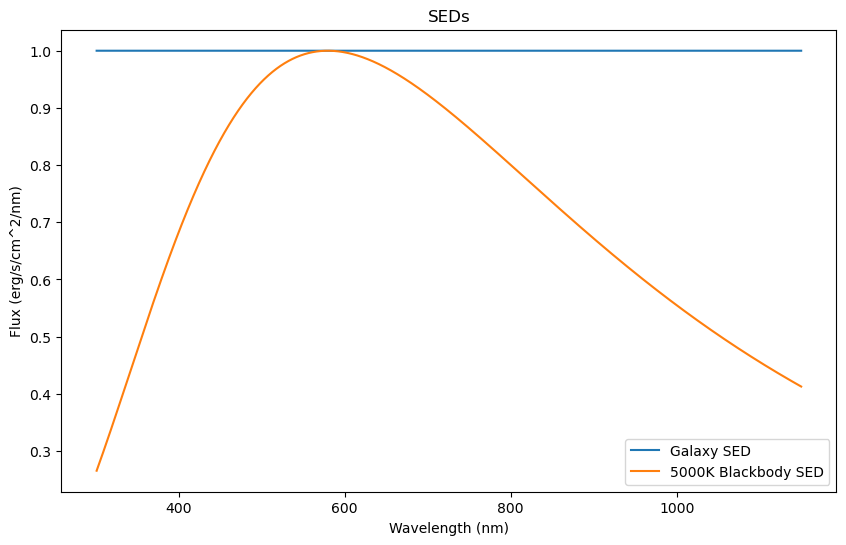

In [37]:

# For a given pointing...

# Knowns (from OpSim)
airmass = 2.0
q = 0 # parallactic angle, degrees
seeing = 1.0 #FWHM, arcseconds
fiducial_wavelength = 500 #nm, for calculating the chromatic seeing contribution

# Derived
zenith = np.arccos(1/airmass) * 180/np.pi # degrees
seeing_var = (seeing / (2 * np.sqrt(2*np.log(2))))**2 # shape moment (variance) assuming 2d gaussian seeing PSF 

# Define the SEDs to compare
wavelengths_data = np.linspace(301, 1150, 10000)

# Galaxy SED 

# Flat: 
flux = np.ones(len(wavelengths_data))
flux_table = galsim.LookupTable(wavelengths_data * 10, flux, interpolant='linear')
galaxy_SED = galsim.SED(flux_table, wave_type='A', flux_type='flambda')

# Load from file:
# file = '1000SEDs.txt'
# data = np.loadtxt(file)
# wvl = data[0]
# flux = np.abs(data[8])
# flux = interp1d(wvl, flux)(wavelengths_data) #interpolate to the same wavelength grid as the filter curves
# flux_table = galsim.LookupTable(wavelengths_data * 10, flux, interpolant='linear')
# galaxy_SED = galsim.SED(flux_table, wave_type='A', flux_type='flambda')

# Stellar SED

BB_flux = BB(wavelengths_data, 5000, 1) # 5000 K Blackbody spectrum
BB_table = galsim.LookupTable(wavelengths_data * 10, BB_flux, interpolant='linear')
BB_SED = galsim.SED(BB_table, wave_type='A', flux_type='flambda')



# Find the mean wavlengths (in photon density space) for each SED for estimating chromatic seeing
mean_wavelength_gal = mean_wavelength_photon_density(galaxy_SED, wavelengths_data)
mean_wavelength_calib = mean_wavelength_photon_density(BB_SED, wavelengths_data)

# for band in filter_labels:
#     print(band, 'mean wavelength galaxy:', np.round(mean_wavelength_flat[band], 2), 'nm', ' mean wavelength BB:', np.round(mean_wavelength_calib[band], 2), 'nm')


# Get the DCR shifts and widths for each SED using the galsim functions 
shifts, widths= get_shifts_galsim(zenith, galaxy_SED)
shifts_calib, widths_calib = get_shifts_galsim(zenith, BB_SED)


# Plot the (normalized) SEDs
plt.figure(figsize=(10,6))
# plt.plot(wavelengths_data, galaxy_SED(wavelengths_data)/galaxy_SED(wavelengths_data).max(), label = 'Galaxy SED')
# plt.plot(wavelengths_data, BB_SED(wavelengths_data)/BB_SED(wavelengths_data).max(), label = '5000K Blackbody SED')
plt.plot(wavelengths_data, flux/np.max(flux), label = 'Galaxy SED')
plt.plot(wavelengths_data, BB_flux/np.max(BB_flux), label = '5000K Blackbody SED')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Flux (erg/s/cm^2/nm)')
plt.title('SEDs')
plt.legend()
plt.show()


In [38]:

# Estimate PSF shape/sizes with chromatic atmospheric seeing and DCR contributions

band = 'g'
gal_seeing_var = seeing_var * (mean_wavelength_gal[band] / fiducial_wavelength)**(-2/5) # shape moment (variance) contribution from chromatic seeing, using a power law with index -0.2
Ixx_gal = gal_seeing_var
Iyy_gal = gal_seeing_var + widths[band] # shape moment along dec includes DCR variance

calib_seeing_var = seeing_var * (mean_wavelength_calib[band] / fiducial_wavelength)**(-2/5) # shape moment (variance) contribution from chromatic seeing, using a power law with index -0.2
Ixx_calib = calib_seeing_var
Iyy_calib = calib_seeing_var + widths_calib[band] # shape moment along dec includes DCR variance for calibration star

T_gal = Ixx_gal + Iyy_gal
T_calib = Ixx_calib + Iyy_calib

error = (T_gal - T_calib) / T_calib

print(band)
print('seeing_var: ', seeing_var)
print('widths (DCR variance): ', widths[band], widths_calib[band])
print('Iyy (gal & calib): ', Iyy_gal, Iyy_calib)
print('T (gal & calib): ', T_gal, T_calib)
print('error: ', error)



g
seeing_var:  0.18033688011112042
widths (DCR variance):  0.10440077500420598 0.09652157987948465
Iyy (gal & calib):  0.2870337002687355 0.2785646615945928
T (gal & calib):  0.469666625533265 0.460607743309701
error:  0.019667238241526972


In [39]:
# Generate two chromatic PSFs with the same seeing but different SED-weighted DCR

zenith_angle = np.arccos(1 / airmass) * galsim.radians
parallactic_angle = q * galsim.degrees
base_wavelength = 500.0  # nm
pixel_scale = 0.02  # arcsec / pixel
stamp_npix = 256

base_psf = galsim.Gaussian(fwhm=seeing)
atmospheric_psf = galsim.ChromaticAtmosphere(
    base_psf,
    base_wavelength=base_wavelength,
    zenith_angle=zenith_angle,
    parallactic_angle=parallactic_angle,
    pressure=pressure,
    temperature=temperature,
    H2O_pressure=H2O_pressure,
)


def measure_image_second_moments(image, scale):
    data = np.asarray(image.array, dtype=float)
    total_flux = data.sum()
    x_coords = (np.arange(data.shape[1]) - (data.shape[1] - 1) / 2.0) * scale
    y_coords = (np.arange(data.shape[0]) - (data.shape[0] - 1) / 2.0) * scale
    xx, yy = np.meshgrid(x_coords, y_coords)

    x_centroid = np.sum(data * xx) / total_flux
    y_centroid = np.sum(data * yy) / total_flux

    dx = xx - x_centroid
    dy = yy - y_centroid
    qxx = np.sum(data * dx * dx) / total_flux
    qyy = np.sum(data * dy * dy) / total_flux
    qxy = np.sum(data * dx * dy) / total_flux
    return {
        'flux': total_flux,
        'x_centroid': x_centroid,
        'y_centroid': y_centroid,
        'qxx': qxx,
        'qyy': qyy,
        'qxy': qxy,
        'trace': qxx + qyy,
    }


def make_chromatic_psf_image(sed, bandpass):
    source = galsim.DeltaFunction() * sed
    chromatic_psf = galsim.Convolve([atmospheric_psf, source]).withFlux(1.0, bandpass)
    image = chromatic_psf.drawImage(
        bandpass=bandpass,
        nx=stamp_npix,
        ny=stamp_npix,
        scale=pixel_scale,
        method='no_pixel',
    )
    moments = measure_image_second_moments(image, pixel_scale)
    return chromatic_psf, image, moments


psf_comparison = {}
psf_images = {}

for band in filter_labels:
    gal_psf, gal_image, gal_moments = make_chromatic_psf_image(galaxy_SED, filters[band])
    bb_psf, bb_image, bb_moments = make_chromatic_psf_image(BB_SED, filters[band])

    relative_trace_error = (gal_moments['trace'] - bb_moments['trace']) / bb_moments['trace']
    relative_image_rms = np.linalg.norm(gal_image.array - bb_image.array) / np.linalg.norm(bb_image.array)

    psf_comparison[band] = {
        'gal_trace': gal_moments['trace'],
        'bb_trace': bb_moments['trace'],
        'relative_trace_error': relative_trace_error,
        'relative_image_rms': relative_image_rms,
        'gal_sigma_equiv': np.sqrt(gal_moments['trace'] / 2.0),
        'bb_sigma_equiv': np.sqrt(bb_moments['trace'] / 2.0),
        'gal_centroid_x': gal_moments['x_centroid'],
        'gal_centroid_y': gal_moments['y_centroid'],
        'bb_centroid_x': bb_moments['x_centroid'],
        'bb_centroid_y': bb_moments['y_centroid'],
    }
    psf_images[band] = {
        'gal': gal_image,
        'bb': bb_image,
    }

    print(
        band,
        'gal T =', np.round(gal_moments['trace'], 6),
        'bb T =', np.round(bb_moments['trace'], 6),
        'relative trace error =', np.round(relative_trace_error, 6),
        'relative image RMS =', np.round(relative_image_rms, 6),
    )


u gal T = 0.459629 bb T = 0.455848 relative trace error = 0.008296 relative image RMS = 0.045467
g gal T = 0.470461 bb T = 0.461354 relative trace error = 0.019739 relative image RMS = 0.042852
r gal T = 0.348739 bb T = 0.34887 relative trace error = -0.000375 relative image RMS = 0.004426
i gal T = 0.310462 bb T = 0.310842 relative trace error = -0.001225 relative image RMS = 0.006967
z gal T = 0.290834 bb T = 0.291061 relative trace error = -0.000781 relative image RMS = 0.00377
y gal T = 0.277601 bb T = 0.277829 relative trace error = -0.000823 relative image RMS = 0.003544


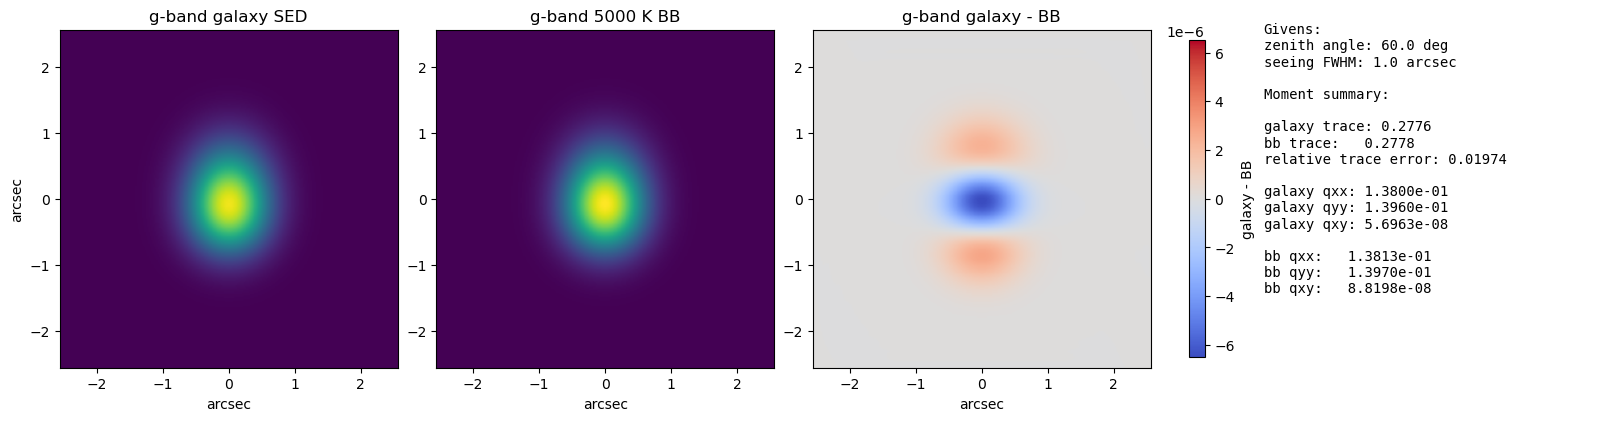

In [40]:
import matplotlib.pyplot as plt
from scipy.ndimage import shift as nd_shift

chosen_band = 'g'  # change this to inspect a different band
gal_img = psf_images[chosen_band]['gal'].array
bb_img = psf_images[chosen_band]['bb'].array

gal_centered = nd_shift(gal_img, shift=(-psf_comparison[chosen_band]['gal_centroid_y'] / pixel_scale, -psf_comparison[chosen_band]['gal_centroid_x'] / pixel_scale), order=3, mode='constant', cval=0.0)
bb_centered = nd_shift(bb_img, shift=(-psf_comparison[chosen_band]['bb_centroid_y'] / pixel_scale, -psf_comparison[chosen_band]['bb_centroid_x'] / pixel_scale), order=3, mode='constant', cval=0.0)
diff_img = gal_centered - bb_centered

half_size_x = gal_img.shape[1] * pixel_scale / 2.0
half_size_y = gal_img.shape[0] * pixel_scale / 2.0
extent = [-half_size_x, half_size_x, -half_size_y, half_size_y]

vmax = max(gal_centered.max(), bb_centered.max())
diff_lim = np.max(np.abs(diff_img))

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4), constrained_layout=True)

axes[0].imshow(gal_centered, origin='lower', extent=extent, cmap='viridis', vmin=0, vmax=vmax)
axes[0].set_title(f'{chosen_band}-band galaxy SED')
axes[0].set_ylabel('arcsec')

axes[1].imshow(bb_centered, origin='lower', extent=extent, cmap='viridis', vmin=0, vmax=vmax)
axes[1].set_title(f'{chosen_band}-band 5000 K BB')

diff_im = axes[2].imshow(diff_img, origin='lower', extent=extent, cmap='coolwarm', vmin=-diff_lim, vmax=diff_lim)
axes[2].set_title(f'{chosen_band}-band galaxy - BB')

gal_trace = np.sum((gal_centered * ((np.arange(gal_centered.shape[0])[:, None] - (gal_centered.shape[0] - 1) / 2.0) * pixel_scale) ** 2)) / np.sum(gal_centered)
bb_trace = np.sum((bb_centered * ((np.arange(bb_centered.shape[0])[:, None] - (bb_centered.shape[0] - 1) / 2.0) * pixel_scale) ** 2)) / np.sum(bb_centered)
relative_trace_error = (gal_trace - bb_trace) / bb_trace
summary_text = (
    f'Givens:\n'
    f'zenith angle: {zenith :.1f} deg\n'
    f'seeing FWHM: {seeing:.1f} arcsec\n\n'
    f'Moment summary:\n\n'
    f'galaxy trace: {gal_moments["trace"]:.4}\n'
    f'bb trace:   {bb_moments["trace"]:.4}\n'
    f'relative trace error: {psf_comparison[chosen_band]["relative_trace_error"]:.4}\n\n'
    f'galaxy qxx: {gal_moments["qxx"]:.4e}\n'
    f'galaxy qyy: {gal_moments["qyy"]:.4e}\n'
    f'galaxy qxy: {gal_moments["qxy"]:.4e}\n\n'
    f'bb qxx:   {bb_moments["qxx"]:.4e}\n'
    f'bb qyy:   {bb_moments["qyy"]:.4e}\n'
    f'bb qxy:   {bb_moments["qxy"]:.4e}\n'
)

axes[3].axis('off')
axes[3].text(0.0, 1.0, summary_text, va='top', ha='left', family='monospace')

for ax in axes[:3]:
    ax.set_xlabel('arcsec')

fig.colorbar(diff_im, ax=axes[2], shrink=0.9, label='galaxy - BB')
plt.show()
